<a href="https://colab.research.google.com/github/andykang2000-hub/Phase-III-Trial-Data-Analysis-and-Predictive-modeling.ipynb/blob/main/Exploratory_Analysis_of_Phase_III_Trial_Data_Survival_Outcomes_and_Adverse_Event_Profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the survival analysis library
!pip install lifelines --quiet

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Survival analysis
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("All libraries loaded successfully")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.3 MB/s eta 0:00:00
All libraries loaded successfully


In [2]:
from lifelines.datasets import load_lung

df = load_lung()
print(df.shape)
df.head()

(228, 10)


,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,1,0.0,100.0,90.0,NaN,0.0


In [3]:
# Check missing values
print("Missing values per column")
print(df.isnull().sum())

Missing values per column
inst          1
time          0
status        0
age           0
sex           0
ph.ecog       1
ph.karno      1
pat.karno     3
meal.cal     47
wt.loss      14
dtype: int64


In [4]:
# Drop rows missing time or status
df = df.dropna(subset=['time', 'status'])

# Convert status to boolean event flag
# 0=censored, 1=dead
df['event'] = df['status'] == 1

# Confirm
print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nEvent (death) counts:")
print(df['event'].value_counts())

Dataset shape after cleaning: (228, 11)

Event (death) counts:
event
True     165
False     63
Name: count, dtype: int64


In [5]:
# Quick statistical summary of survival time
print("Survival time summary (days):")
print(df['time'].describe())
print(f"\nMedian survival time: {df['time'].median()} days")

Survival time summary (days):
count     228.000000
mean      305.232456
std       210.645543
min         5.000000
25%       166.750000
50%       255.500000
75%       396.500000
max      1022.000000
Name: time, dtype: float64

Median survival time: 255.5 days


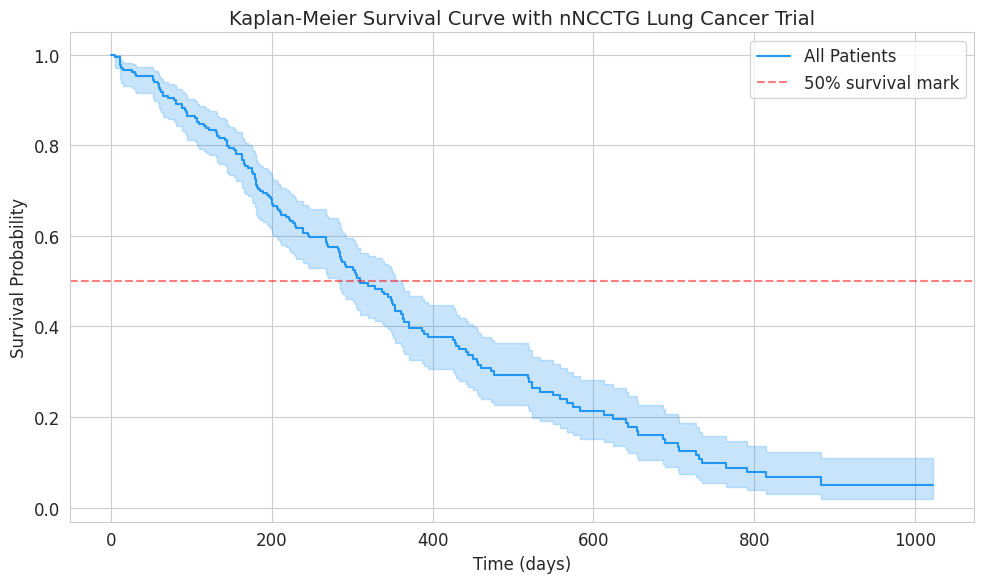

Median survival time: 310.0 days


In [6]:
# KM curve starts at 100% survival, and steps downward each time a death occurs

# Initiate the fitter
kmf = KaplanMeierFitter()

# Fit to our data
kmf.fit(durations=df['time'], event_observed=df['event'])

# Plot
plt.figure(figsize=(10,6))
kmf.plot_survival_function(
    ci_show=True,
    color='#2196F3',
    label='All Patients'
)

plt.title('Kaplan-Meier Survival Curve with nNCCTG Lung Cancer Trial', fontsize=14)
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% survival mark')
plt.legend()
plt.tight_layout()
plt.show()

# Print the median survival time from the fitter
print(f"Median survival time: {kmf.median_survival_time_} days")


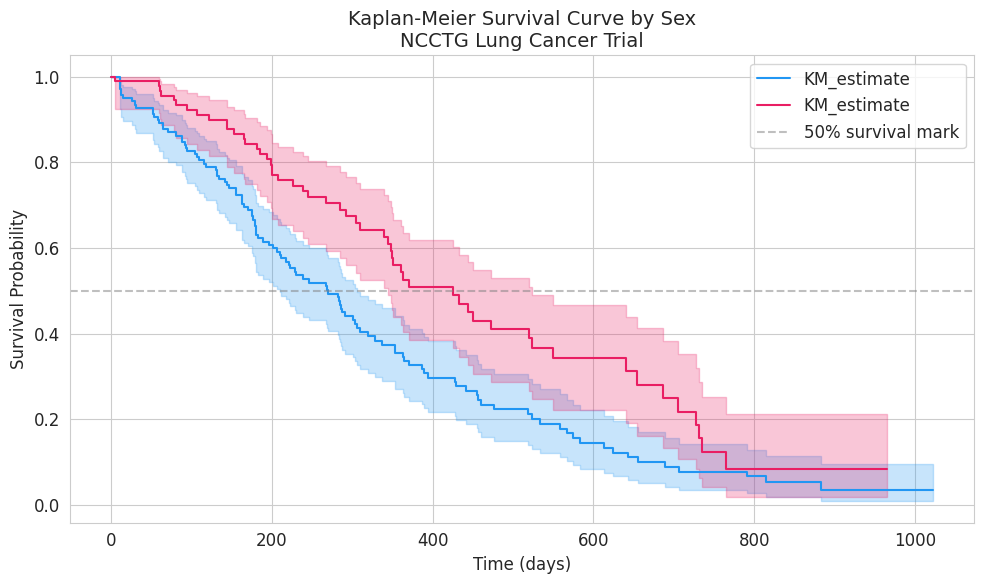

Median survival — Male: 270.0 days
Median survival — Female: 426.0 days


In [7]:
# Survival by Sex

# Split by sex: 1=Male, 2=Female
male = df[df['sex'] == 1]
female = df[df['sex'] == 2]

# Fit separately
kmf_male = KaplanMeierFitter()
kmf_female = KaplanMeierFitter()

kmf_male.fit(durations=male['time'], event_observed=male['event'])
kmf_female.fit(durations=female['time'], event_observed=female['event'])

# Plot both on same chart
plt.figure(figsize=(10,6))
kmf_male.plot_survival_function(ci_show=True, color='#2196F3')
kmf_female.plot_survival_function(ci_show=True, color='#E91E63')

plt.title('Kaplan-Meier Survival Curve by Sex\nNCCTG Lung Cancer Trial', fontsize=14)
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% survival mark')
plt.legend()
plt.tight_layout()
plt.show()

# Print median survival for each group
print(f"Median survival — Male: {kmf_male.median_survival_time_} days")
print(f"Median survival — Female: {kmf_female.median_survival_time_} days")

In [8]:
# Log-rank test: are the two survival curves statistically different?
results = logrank_test(
    male['time'], female['time'],
    event_observed_A=male['event'],
    event_observed_B=female['event']
)

print(f"Logrank test p-value: {results.p_value:.4f}")

if results.p_value <0.05:
  print("Statistically significant difference between Male & Female (p<0.05)")
else:
    print("No statistically significant difference detected (p ≥ 0.05)")

Logrank test p-value: 0.0013
Statistically significant difference between Male & Female (p<0.05)


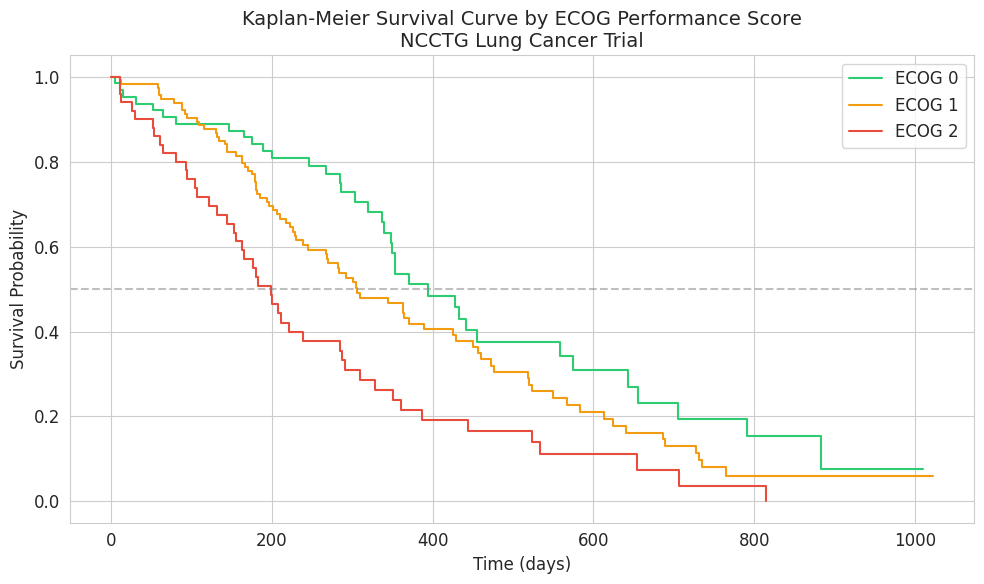

Median survival by ECOG score:
  ECOG 0: 394.0 days
  ECOG 1: 306.0 days
  ECOG 2: 199.0 days


In [9]:
# ECOG scores: 0=fully active, 1=restricted but ambulatory, 2=limited self-care, 3=confined to bed
# Drop missing ECOG values
df_ecog = df.dropna(subset=['ph.ecog'])

# Only use scores 0-2 (score 3 has very few patients)
df_ecog = df_ecog[df_ecog['ph.ecog'] <= 2]

plt.figure(figsize=(10, 6))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
for score, color in zip([0, 1, 2], colors):
    mask = df_ecog['ph.ecog'] == score
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(
        durations=df_ecog[mask]['time'],
        event_observed=df_ecog[mask]['event'],
        label=f'ECOG {int(score)}'
    )
    kmf_temp.plot_survival_function(ci_show=False, color=color)

plt.title('Kaplan-Meier Survival Curve by ECOG Performance Score\nNCCTG Lung Cancer Trial', fontsize=14)
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Median survival per ECOG group
print("Median survival by ECOG score:")
for score in [0, 1, 2]:
    mask = df_ecog['ph.ecog'] == score
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df_ecog[mask]['time'], event_observed=df_ecog[mask]['event'])
    print(f"  ECOG {int(score)}: {kmf_temp.median_survival_time_} days")

In [19]:
# Multivariate log-rank test for ECOG score
results_ecog = multivariate_logrank_test(
    df_ecog['time'],
    df_ecog['ph.ecog'],
    event_col=df_ecog['event']
)

print(f"Log-rank test p-value (ECOG score vs survival): {results_ecog.p_value:.4f}")

if results_ecog.p_value < 0.05:
    print("→ ECOG score has a statistically significant effect on survival (p < 0.05)")
else:
    print("→ No statistically significant relationship detected (p ≥ 0.05)")

Log-rank test p-value (ECOG score vs survival): 0.0093
→ ECOG score has a statistically significant effect on survival (p < 0.05)


/tmp/ipykernel_4537/3137801661.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ae['wt_category'] = df_ae['wt.loss'].apply(categorise_wt_loss)


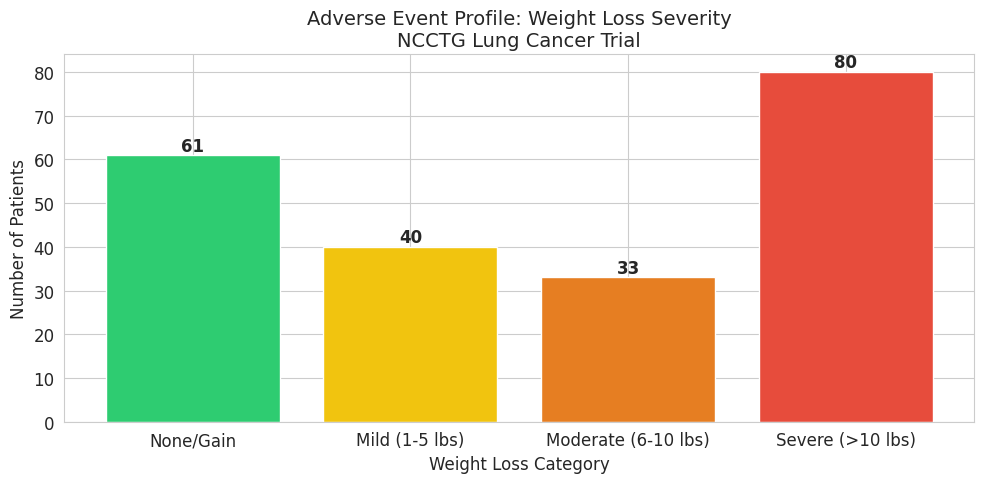


Adverse event frequency table:
                     Count  Percentage
None/Gain               61        28.5
Mild (1-5 lbs)          40        18.7
Moderate (6-10 lbs)     33        15.4
Severe (>10 lbs)        80        37.4


In [11]:
# We'll use weight loss as a proxy adverse event marker
# In real trials you'd have a dedicated AE table — this demonstrates the methodology

df_ae = df.dropna(subset=['wt.loss'])

# Categorise weight loss severity
def categorise_wt_loss(wt):
    if wt <= 0:
        return 'None/Gain'
    elif wt <= 5:
        return 'Mild (1-5 lbs)'
    elif wt <= 10:
        return 'Moderate (6-10 lbs)'
    else:
        return 'Severe (>10 lbs)'

df_ae['wt_category'] = df_ae['wt.loss'].apply(categorise_wt_loss)

# Count and plot
plt.figure(figsize=(10, 5))
order = ['None/Gain', 'Mild (1-5 lbs)', 'Moderate (6-10 lbs)', 'Severe (>10 lbs)']
ae_counts = df_ae['wt_category'].value_counts().reindex(order)

bars = plt.bar(order, ae_counts.values, color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
plt.title('Adverse Event Profile: Weight Loss Severity\nNCCTG Lung Cancer Trial', fontsize=14)
plt.xlabel('Weight Loss Category')
plt.ylabel('Number of Patients')

# Add count labels on bars
for bar, count in zip(bars, ae_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAdverse event frequency table:")
ae_freq = pd.DataFrame({
    'Count': ae_counts.values,
    'Percentage': (ae_counts.values / ae_counts.sum() * 100).round(1)
}, index=order)
print(ae_freq)

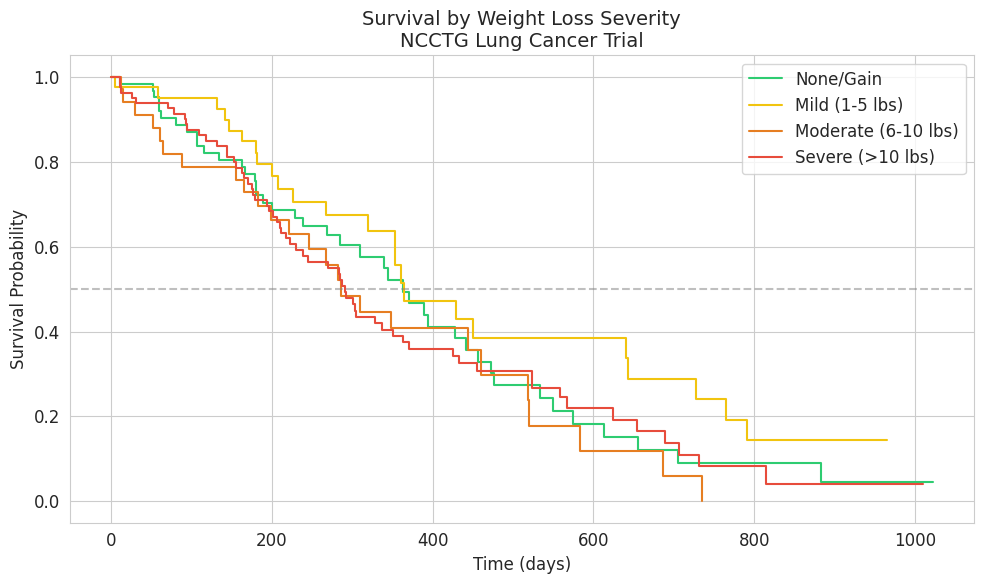

In [12]:
# KM curve split by weight loss severity — does it predict survival?
plt.figure(figsize=(10, 6))

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
for category, color in zip(order, colors):
    mask = df_ae['wt_category'] == category
    if mask.sum() < 5:  # Skip groups too small to be meaningful(filtering)
        continue
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(
        durations=df_ae[mask]['time'],
        event_observed=df_ae[mask]['event'],
        label=category
    )
    kmf_temp.plot_survival_function(ci_show=False, color=color)

plt.title('Survival by Weight Loss Severity\nNCCTG Lung Cancer Trial', fontsize=14)
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
from lifelines.statistics import multivariate_logrank_test

# Multivariate log-rank test — compares all groups simultaneously
results_ae = multivariate_logrank_test(
    df_ae['time'],
    df_ae['wt_category'],
    event_col=df_ae['event']
)

print(f"Log-rank test p-value (weight loss severity vs survival): {results_ae.p_value:.4f}")

if results_ae.p_value < 0.05:
    print("→ Weight loss severity has a statistically significant effect on survival (p < 0.05)")
else:
    print("→ No statistically significant relationship detected (p ≥ 0.05)")

Log-rank test p-value (weight loss severity vs survival): 0.6055
→ No statistically significant relationship detected (p ≥ 0.05)


In [14]:
print("Median survival by weight loss severity:")
print("-" * 45)

for category in order:
    mask = df_ae['wt_category'] == category
    if mask.sum() < 5:
        continue
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df_ae[mask]['time'], event_observed=df_ae[mask]['event'])
    n = mask.sum()
    median = kmf_temp.median_survival_time_
    print(f"  {category:<25} n={n:<4} median={median} days")

Median survival by weight loss severity:
---------------------------------------------
  None/Gain                 n=61   median=363.0 days
  Mild (1-5 lbs)            n=40   median=364.0 days
  Moderate (6-10 lbs)       n=33   median=286.0 days
  Severe (>10 lbs)          n=80   median=291.0 days


In [16]:
# Weight loss severity showed a descriptive trend toward shorter median survival
# However this did not reach statistical significance (p = 0.61)
# likely due to limited sample size per subgroup?

df_ae['wt_category'].value_counts()

,count
wt_category,
Severe (>10 lbs),80
None/Gain,61
Mild (1-5 lbs),40
Moderate (6-10 lbs),33


In [20]:
# ECOG median survivals
ecog_medians = {}
for score in [0, 1, 2]:
    mask = df_ecog['ph.ecog'] == score
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df_ecog[mask]['time'], event_observed=df_ecog[mask]['event'])
    ecog_medians[score] = kmf_temp.median_survival_time_

# Build summary table
summary_data = {
    'Analysis': [
        # Overall
        'Overall median survival',
        '',
        # Sex
        'Median survival — Male',
        'Median survival — Female',
        'Sex difference (log-rank)',
        '',
        # ECOG
        'Median survival — ECOG 0',
        'Median survival — ECOG 1',
        'Median survival — ECOG 2',
        'ECOG vs survival (log-rank)',
        '',
        # Weight loss
        'Median survival — None/Gain',
        'Median survival — Mild (1-5 lbs)',
        'Median survival — Moderate (6-10 lbs)',
        'Median survival — Severe (>10 lbs)',
        'Weight loss vs survival (log-rank)',
    ],
    'Result': [
        '255.5 days',
        '',
        '270.0 days',
        '426.0 days',
        'p = 0.0013 ✓ Significant',
        '',
        f'{ecog_medians[0]} days',
        f'{ecog_medians[1]} days',
        f'{ecog_medians[2]} days',
        'p = 0.0093 ✓ Significant',
        '',
        '363.0 days',
        '364.0 days',
        '286.0 days',
        '291.0 days',
        'p = 0.6055 ✗ Not significant',
    ]
}

summary_df = pd.DataFrame(summary_data)

print("=" * 60)
print("PROJECT A — ANALYSIS SUMMARY")
print("NCCTG Lung Cancer Phase III Trial")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

PROJECT A — ANALYSIS SUMMARY
NCCTG Lung Cancer Phase III Trial
                             Analysis                       Result
              Overall median survival                   255.5 days
                                                                  
               Median survival — Male                   270.0 days
             Median survival — Female                   426.0 days
            Sex difference (log-rank)     p = 0.0013 ✓ Significant
                                                                  
             Median survival — ECOG 0                   394.0 days
             Median survival — ECOG 1                   306.0 days
             Median survival — ECOG 2                   199.0 days
          ECOG vs survival (log-rank)     p = 0.0093 ✓ Significant
                                                                  
          Median survival — None/Gain                   363.0 days
     Median survival — Mild (1-5 lbs)                   364.0 days

**Dataset:** NCCTG Lung Cancer Trial (Loprinzi et al., 1994)
228 patients | 165 events (death) | 63 censored

---

**1. Overall Survival**
Median survival across all patients was 255.5 days (~8.5 months),
consistent with published literature for advanced lung cancer.

---

**2. Survival by Sex (p = 0.0013 ✓)**
Female patients demonstrated significantly longer median survival
(426 days) compared to male patients (270 days) — a difference
of 156 days. This finding is statistically significant and
consistent with known sex-based differences in lung cancer prognosis.

---

**3. Survival by ECOG Performance Score (p = 0.0093 ✓)**
A clear stepwise relationship was observed: patients with better
functional status survived longest (ECOG 0), with survival
declining progressively through ECOG 1 and ECOG 2. This confirms
ECOG score as a strong and statistically significant prognostic
indicator in this cohort.

---

**4. Adverse Event Profile — Weight Loss (p = 0.6055 ✗)**
Severe weight loss (>10 lbs) was the most common adverse event
category (n=80, 37% of patients with recorded weight data).

A threshold effect was observed rather than a smooth gradient:
patients with no weight loss or mild loss showed near-identical
median survival (363 vs 364 days), while both moderate and severe
loss groups showed a step down to approximately 286–291 days.
Despite this descriptive pattern, the difference did not reach
statistical significance, likely due to limited power from
unequal and small subgroup sizes.

---

**Limitations**
- Weight loss used as proxy AE marker (no dedicated AE table)
- meal.cal missing in ~20% of patients (47/228)
- Small subgroup sizes limit statistical power for AE analysis
- Single-institution data may limit generalisability